In [11]:
import os
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf
import librosa.display
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, callbacks, losses
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [12]:
def create_melspectrogram(segmented_dir, n_mels=128):
    segmented_dir = Path(segmented_dir)
    X = []
    y = []
    labels = [f.name for f in segmented_dir.iterdir() if f.is_dir()]

    for label in tqdm(labels):
        for audio in (segmented_dir / label).iterdir():
            if audio.suffix == ".wav":
                signal, sr = librosa.load(audio, sr=None)
                melspectrogram = librosa.feature.melspectrogram(y=signal, 
                                                                sr=sr, 
                                                                n_mels=n_mels, 
                                                                fmax=sr/2)
                melspectrogram_db = librosa.power_to_db(melspectrogram, ref=np.max)
                X.append(melspectrogram_db)
                y.append(label)
            
    X = np.array(X)
    X = np.expand_dims(X, axis=-1)

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)

    return X, np.array(y), label_encoder

Import data for model

In [13]:
X, y, label_encoder = create_melspectrogram('IRMAS_segmented')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=1)

100%|██████████| 11/11 [01:50<00:00, 10.02s/it]


Plot mel spectrogram

In [14]:
def plot_melspectrogram(X, i=0):
    melspectrogram_sample = X[i, :, :, 0]
    librosa.display.specshow(melspectrogram_sample, x_axis='time', y_axis='mel', cmap='viridis')
    plt.colorbar(label='Amplitude')
    plt.title('Mel Spectrogram')
    plt.xlabel('Time Frames')
    plt.ylabel('Mel Frequency Bands')
    plt.show()

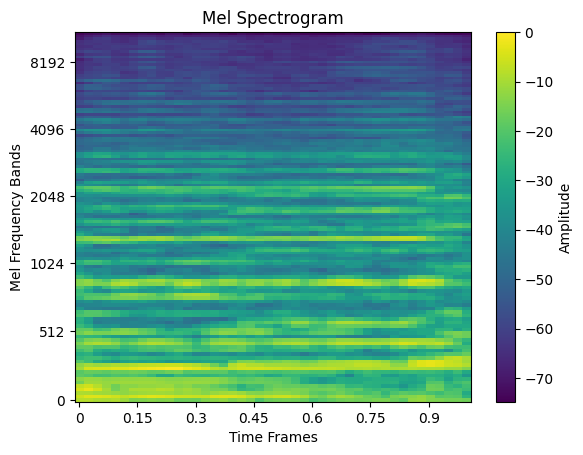

In [15]:
plot_melspectrogram(X)

CNN model

In [16]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(X.shape[1], X.shape[2], 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.3),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.4),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(np.unique(y)), activation='softmax')
])

cnn.compile(optimizer='adam',
            loss=losses.SparseCategoricalCrossentropy(),
            metrics=['accuracy'])

c:\Users\grzes\anaconda3\envs\audio\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Train CNN

In [17]:
early_stopping = callbacks.EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)

history = cnn.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    class_weight=class_weights_dict
)

Epoch 1/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.2389 - loss: 2.2466 - val_accuracy: 0.2153 - val_loss: 2.7154
Epoch 2/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.3997 - loss: 1.8097 - val_accuracy: 0.3368 - val_loss: 2.0649
Epoch 3/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.4599 - loss: 1.6252 - val_accuracy: 0.2724 - val_loss: 2.3133
Epoch 4/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.5070 - loss: 1.5038 - val_accuracy: 0.3197 - val_loss: 2.6791
Epoch 5/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.5423 - loss: 1.4363 - val_accuracy: 0.2330 - val_loss: 3.4174
Epoch 6/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.5437 - loss: 1.3867 - val_accuracy: 0.4362 - val_loss: 1.7648
Epoch 7/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.5676 - loss: 1.3127 - val_accuracy: 0.3669 - val_loss: 1.9091
Epoch 8/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.5809 - loss: 1

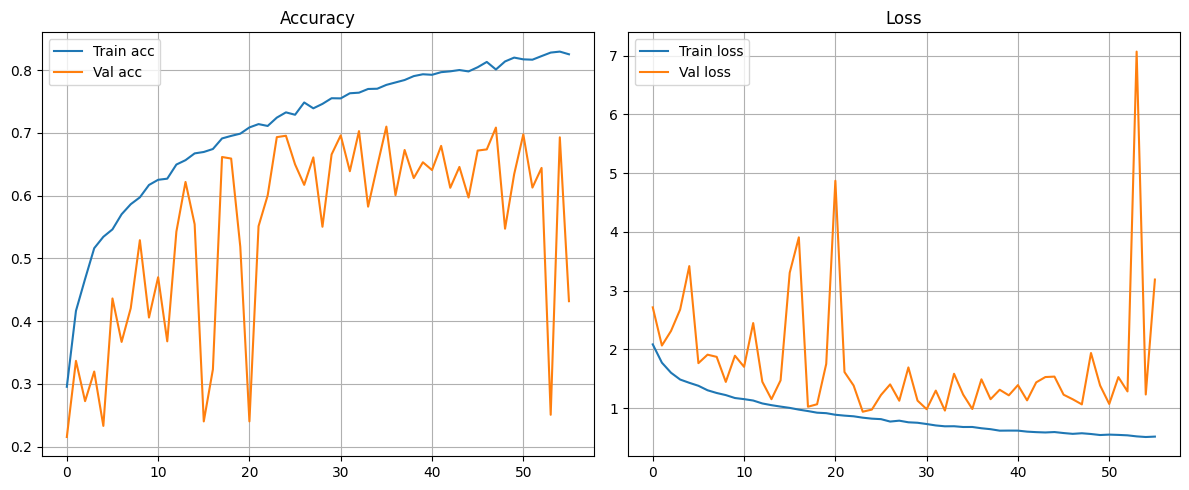

In [18]:
# with open("IRMAS_cnn_melspectogram_history.pkl", "wb") as f:
#     pickle.dump(history.history, f)
    
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train acc')
plt.plot(history.history['val_accuracy'], label='Val acc')
plt.title('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
# plt.savefig("IRMAS_cnn_melspectogram_training_curves.png")
plt.show()

Evaluate CNN

In [19]:
y_pred = cnn.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

y_pred_labels = label_encoder.inverse_transform(y_pred)
y_test_labels = label_encoder.inverse_transform(y_test)

accuracy = accuracy_score(y_test_labels, y_pred_labels)
class_report = classification_report(y_test_labels, y_pred_labels)

print('Accuracy:', accuracy)
print('\nClassification Report:\n', class_report)

# output_file = 'cnn_melspectrogram_evaluation.txt'

# with open(output_file, 'w') as file:
#     file.write(f'Accuracy: {accuracy}\n')
#     file.write('\nClassification Report:\n')
#     file.write(class_report)

# best .71

126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Accuracy: 0.7024608501118568

Classification Report:
               precision    recall  f1-score   support

         cel       0.60      0.86      0.70       233
         cla       0.73      0.69      0.71       303
         flu       0.73      0.58      0.65       270
         gac       0.60      0.82      0.69       382
         gel       0.67      0.58      0.62       456
         org       0.67      0.93      0.78       409
         pia       0.66      0.87      0.75       433
         sax       0.73      0.44      0.55       376
         tru       0.78      0.77      0.77       346
         vio       0.77      0.45      0.57       348
         voi       0.94      0.71      0.81       467

    accuracy                           0.70      4023
   macro avg       0.72      0.70      0.69      4023
weighted avg       0.72      0.70      0.70      4023



Save CNN

In [20]:
# cnn.save('cnn_melspectrogram_model.h5')